In [218]:
import pyro
import torch
from pyro import distributions as dist
import matplotlib.pyplot as plt
import numpy as np
import random
import arviz as az
from pyro.infer import MCMC, NUTS, Predictive, EmpiricalMarginal
from pyro.infer.autoguide import init_to_mean, init_to_median, init_to_value
from pyro.infer.mcmc.util import summary

from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam



In [219]:

import gempy as gp
import gempy_viewer as gpv
import gempy_engine
from gempy.core.data import Grid
from gempy_engine.core.backend_tensor import BackendTensor

Setting Backend To: AvailableBackends.numpy


/Users/deepprakashravi/miniforge3/envs/gempy3/lib/python3.10/site-packages/gempy_engine/API/dual_contouring/multi_scalar_dual_contouring.py:48: UserWarning: Fancy triangulation only works with regular grid of resolution [2,2,2]. Defaulting to regular triangulation
  warnings.warn("Fancy triangulation only works with regular grid of resolution [2,2,2]. Defaulting to regular triangulation")
/Users/deepprakashravi/miniforge3/envs/gempy3/lib/python3.10/site-packages/gempy_viewer/API/_plot_2d_API.py:172: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


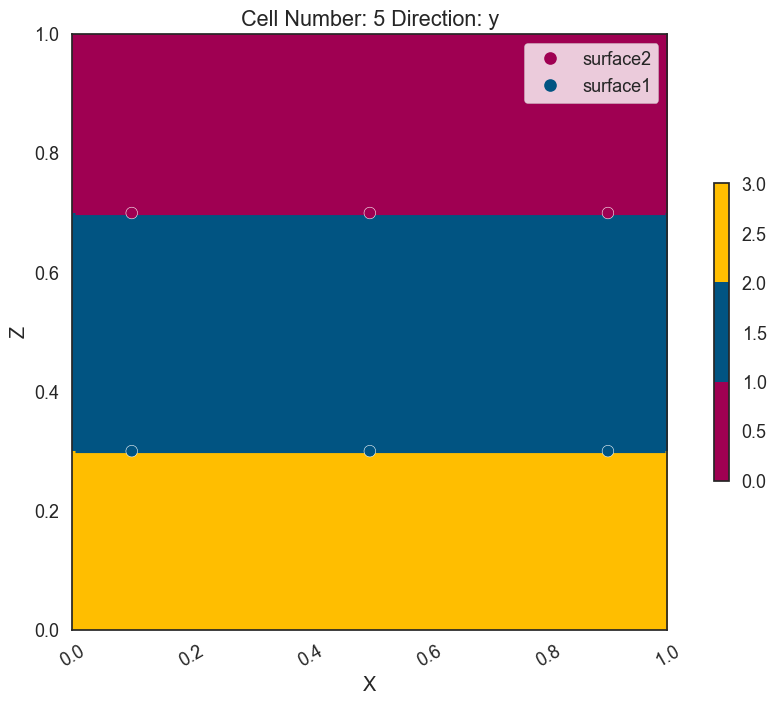

In [220]:
geo_model_test = gp.create_geomodel(
    project_name='Gempy_abc_Test',  
    extent=[0, 1, -0.1, 0.1, 0, 1], 
    resolution=[100,10,100],             
    #refinement=7,
    structural_frame= gp.data.StructuralFrame.initialize_default_structure()
    )
   
brk1 = 0.3
brk2 = 0.7
grad = 1.0
gp.add_surface_points(
    geo_model=geo_model_test,
    x=[0.1, 0.5, 0.9],
    y=[0.0, 0.0, 0.0],
    z=[brk1 , brk1 , brk1],
    elements_names=['surface1', 'surface1', 'surface1']
)

gp.add_orientations(
    geo_model=geo_model_test,
    x=[-0.1, 1.1],
    y=[0.0, 0.0],
    z=[brk1, brk1],
    elements_names=['surface1', 'surface1'],
    pole_vector=[[0, 0, grad], [0, 0, grad]]
)
geo_model_test.update_transform(gp.data.GlobalAnisotropy.NONE)



element2 = gp.data.StructuralElement(
    name='surface2',
    color=next(geo_model_test.structural_frame.color_generator),
    surface_points=gp.data.SurfacePointsTable.from_arrays(
        x=[ 0.1, 0.5, 0.9],
        y=[ 0.0, 0.0, 0.0],
        z=np.array([brk2, brk2, brk2]),
        names='surface2'
    ),
    orientations=gp.data.OrientationsTable.initialize_empty()
)


geo_model_test.update_transform(gp.data.GlobalAnisotropy.NONE)
geo_model_test.structural_frame.structural_groups[0].append_element(element2)

gp.add_orientations(
    geo_model=geo_model_test,
    x=[-0.1, 1.1],
    y=[0.0, 0.0],
    z=[brk2, brk2],
    elements_names=['surface2', 'surface2'],
    pole_vector=[[0, 0, grad], [0, 0, grad]]
)
geo_model_test.update_transform(gp.data.GlobalAnisotropy.NONE)

num_elements = len(geo_model_test.structural_frame.structural_groups[0].elements) - 1  # Number of elements - 1 for zero-based index
for swap_length in range(num_elements, 0, -1):  
    for i in range(swap_length):
        # Perform the swap for each pair (i, i+1)
        geo_model_test.structural_frame.structural_groups[0].elements[i], geo_model_test.structural_frame.structural_groups[0].elements[i + 1] = \
        geo_model_test.structural_frame.structural_groups[0].elements[i + 1], geo_model_test.structural_frame.structural_groups[0].elements[i]


sol = gp.compute_model(geo_model_test)

# gpv.plot_3d(geo_model_test, legend='force')
picture_test = gpv.plot_2d(geo_model_test, cell_number=5, legend='force')


In [221]:
geo_model_test.interpolation_options.sigmoid_slope

50000

In [222]:
df_sp_init = geo_model_test.surface_points.df
df_sp_init

,X,Y,Z,id,nugget
0,0.1,0.0,0.7,3887912,0.00001
1,0.5,0.0,0.7,3887912,0.00001
2,0.9,0.0,0.7,3887912,0.00001
3,0.1,0.0,0.3,20553520,0.00001
4,0.5,0.0,0.3,20553520,0.00001
5,0.9,0.0,0.3,20553520,0.00001


In [223]:
geo_model_test.grid.deactivate_all_grids()

array([False, False, False, False, False])

In [224]:
N = 50  # number of points

z = np.linspace(0, 1, N)
x = np.full(N, 0.5)
y = np.full(N, 0.0)

xyz_coord = np.vstack((x, y, z)).T

gp.set_custom_grid(geo_model_test.grid, xyz_coord=xyz_coord)
geo_model_test.interpolation_options.mesh_extraction = False
geo_model_test.interpolation_options.sigmoid_slope = 1000
gp.compute_model(geo_model_test)
output = geo_model_test.solutions.octrees_output[0].last_output_center.custom_grid_values

output
    

Active grids: ['custom']
Setting Backend To: AvailableBackends.numpy


array([3.        , 3.        , 3.        , 3.        , 3.        ,
       3.        , 3.        , 3.        , 3.        , 3.        ,
       3.        , 3.        , 3.        , 3.        , 2.99999324,
       2.00604729, 2.        , 2.        , 2.        , 2.        ,
       2.        , 2.        , 2.        , 2.        , 2.        ,
       2.        , 2.        , 2.        , 2.        , 2.        ,
       2.        , 2.        , 2.        , 2.        , 1.99395271,
       1.00000676, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

In [225]:
geo_model_test.grid.active_grids

array(['custom'], dtype='<U10')

In [226]:
regular_sol2 = geo_model_test.solutions.octrees_output[0].last_output_center.values_block
regular_sol2

array([[3., 3., 3., ..., 1., 1., 1.]])

In [227]:
obs = output + np.random.normal(0, 0.05, size=output.shape)
obs

array([2.93636841, 3.07157478, 2.99644713, 2.99247989, 2.95566129,
       2.94871884, 2.88938449, 2.98550275, 3.04975913, 2.91408363,
       2.95261855, 3.00770793, 3.00539033, 2.94333024, 2.93078225,
       1.9338184 , 2.01851923, 2.01441587, 2.00226261, 2.02711951,
       2.15714215, 1.92018756, 2.03393262, 1.91995678, 1.97512333,
       1.99232758, 2.14981548, 2.06712936, 2.06723661, 2.02904373,
       1.93459127, 2.0646813 , 1.94061173, 2.03598783, 2.00806239,
       1.06567087, 1.03601311, 0.94556374, 0.98938764, 1.01494394,
       1.02975351, 0.96056475, 1.04101926, 1.02006136, 1.03024431,
       1.05842853, 1.00708537, 1.01694996, 0.95062966, 0.98630631])

In [228]:
sp_coords_copy_test = geo_model_test.interpolation_input.surface_points.sp_coords.copy()
sp_coords_copy_test

array([[-0.16666667,  0.        ,  0.08333333],
       [ 0.        ,  0.        ,  0.08333333],
       [ 0.16666667,  0.        ,  0.08333333],
       [-0.16666667,  0.        , -0.08333333],
       [ 0.        ,  0.        , -0.08333333],
       [ 0.16666667,  0.        , -0.08333333]])

In [229]:
BackendTensor.change_backend_gempy(engine_backend=gp.data.AvailableBackends.PYTORCH)

Setting Backend To: AvailableBackends.PYTORCH


In [230]:
def model(geo_model_test, obs):
    
    
    mu1 = pyro.sample('mu1', dist.Normal(torch.tensor(0.08333333, dtype=torch.float64), torch.tensor(0.08, dtype=torch.float64)))
    mu2 = pyro.sample('mu2', dist.Normal(torch.tensor(-0.08333333, dtype=torch.float64), torch.tensor(0.08, dtype=torch.float64)))
    
    interpolation_input = geo_model_test.interpolation_input
    
    
    interpolation_input.surface_points.sp_coords = torch.index_put(
                            interpolation_input.surface_points.sp_coords,
                            (torch.tensor([1]), torch.tensor([2])),
                            mu1)
    interpolation_input.surface_points.sp_coords = torch.index_put(
                            interpolation_input.surface_points.sp_coords,
                            (torch.tensor([4]), torch.tensor([2])),
                            mu2)
    # # Compute the geological model
    
    
    geo_model_test.solutions = gempy_engine.compute_model(
        interpolation_input=interpolation_input,
        options=geo_model_test.interpolation_options,
        data_descriptor=geo_model_test.input_data_descriptor,
        geophysics_input=geo_model_test.geophysics_input,
    )
    
    # Compute and observe the thickness of the geological layer
    custom_grid_values = geo_model_test.solutions.octrees_output[0].last_output_center.custom_grid_values
    
    with pyro.plate("data", len(obs)):
        pyro.sample("obs", dist.Normal(custom_grid_values, 0.05), obs=torch.tensor(obs, dtype=torch.float64))
    
    # log_likelihood = dist.Normal(custom_grid_values, 0.05).log_prob(torch.tensor(obs, dtype=torch.float64))  # (N, K)
    # # Always write pyro.factor outside the pyro plate, otherwise the likelihood will be multiplied with number of plate dim
    # pyro.factor("log_likelihood", log_likelihood.sum())  # Scalar log joint 
    
    
    

pyro.clear_param_store()
dot = pyro.render_model(model, model_args=(geo_model_test, obs), render_distributions=True, filename="Bayesian_Gempy_Model.png")
    

Condition number: 2826.063641983205.


In [231]:
prior = Predictive(model,num_samples=100)(geo_model_test, obs)
data_post = az.from_pyro(prior=prior)
pyro.primitives.enable_validation(is_validate=True)
nuts_kernel = NUTS(model, step_size=0.0085, adapt_step_size=True, target_accept_prob=0.6, max_tree_depth=10, init_strategy=init_to_mean)
mcmc = MCMC(nuts_kernel, num_samples=100, warmup_steps=100, num_chains=1)
mcmc.run(geo_model_test, obs)
samples = mcmc.get_samples()


Condition number: 2826.063641983205.
Condition number: 8312.346640740803.
Condition number: 6095.3232835753215.
Condition number: 6010.868797558038.
Condition number: 3036.053941655609.
Condition number: 4215.504105673039.
Condition number: 2645.712236336688.
Condition number: 3214.81399721351.
Condition number: 2629.7160265974967.
Condition number: 5523.47805199384.
Condition number: 2592.2622870949644.
Condition number: 2991.0546751710863.
Condition number: 3535.853625813186.
Condition number: 2182.2047300133468.
Condition number: 3788.4696126695353.
Condition number: 2812.1083067408968.
Condition number: 2275.339012785218.
Condition number: 6348.981076145742.
Condition number: 8255.36370802491.
Condition number: 3340.5844776265726.
Condition number: 5526.50281138602.
Condition number: 3183.9387375575407.
Condition number: 6398.389366223027.
Condition number: 2458.0823151338577.
Condition number: 3293.4097906300594.
Condition number: 8220.690486586369.
Condition number: 2190.24539154

Warmup:   0%|          | 0/200 [00:00, ?it/s]

Condition number: 4472.039812811413.
Condition number: 4381.140739809132.
Condition number: 4381.140739809132.
Condition number: 4381.140739809132.
Condition number: 4381.140739809132.
Condition number: 4381.140739809132.
Condition number: 3904.466127406669.
Condition number: 4381.140739809132.
Condition number: 4075.8902012403273.
Condition number: 4381.140739809132.
Condition number: 4422.973514447438.
Condition number: 4381.140739809132.
Condition number: 4383.9546611327205.
Condition number: 4381.140739809132.
Condition number: 4387.776196872073.
Condition number: 4396.098146931088.
Condition number: 4405.100895614573.
Condition number: 4406.38159670784.
Condition number: 4362.578365959651.
Condition number: 4342.173246145082.
Condition number: 4320.926453632033.
Condition number: 4299.33231572792.


Warmup:   0%|          | 1/200 [00:27, 27.43s/it, step size=1.09e-02, acc. prob=0.997]

Condition number: 4488.059479585372.


...

Sample:  99%|█████████▉| 198/200 [30:13,  7.10s/it, step size=3.81e-02, acc. prob=0.937]

Condition number: 4155.124062215824.
Condition number: 4181.900086476625.
Condition number: 4198.631988711213.
Condition number: 4212.765609936766.
Condition number: 4224.65416270664.
Condition number: 4234.673081238845.
Condition number: 4243.047038157641.
Condition number: 4249.861478226197.
Condition number: 4255.073904090557.
Condition number: 4258.499061481313.
Condition number: 4259.760945443237.
Condition number: 4258.21672028059.
Condition number: 4252.957241505027.
Condition number: 4243.644215130277.
Condition number: 4236.169849611671.


Sample: 100%|█████████▉| 199/200 [30:24,  8.14s/it, step size=3.81e-02, acc. prob=0.937]

Condition number: 4245.150058032879.
Condition number: 4239.370390759618.
Condition number: 4234.031836117221.
Condition number: 4245.658171601312.
Condition number: 4244.438855892205.
Condition number: 4241.227044028747.
Condition number: 4235.6010886206905.


Sample: 100%|██████████| 200/200 [30:28,  9.14s/it, step size=3.81e-02, acc. prob=0.937]


Condition number: 6366.556760669461.
Condition number: 2918.1380794123693.
Condition number: 4193.261318152679.
Condition number: 4168.148108338524.
Condition number: 4141.997167650228.
Condition number: 4129.187972868774.
Condition number: 4130.377272771701.
Condition number: 4141.22636506726.
Condition number: 4141.217006100283.
Condition number: 4233.934971109149.
Condition number: 4227.800698473676.
Condition number: 4253.322439974256.
Condition number: 4179.01063003147.
Condition number: 4314.288696614213.
Condition number: 4323.447697117805.
Condition number: 4311.467762385463.
Condition number: 4232.901718324806.
Condition number: 4195.196738938957.
Condition number: 4145.0375950625175.
Condition number: 4190.021977086222.
Condition number: 4212.287761565694.
Condition number: 4178.074219631983.
Condition number: 4220.140592848654.
Condition number: 4249.63551641622.
Condition number: 4223.01160462876.
Condition number: 4212.3585913029665.
Condition number: 4195.198512714676.
Co

/Users/deepprakashravi/miniforge3/envs/gempy3/lib/python3.10/site-packages/arviz/data/io_pyro.py:157: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


array([[<Axes: title={'center': 'mu1'}>, <Axes: title={'center': 'mu2'}>]],
      dtype=object)

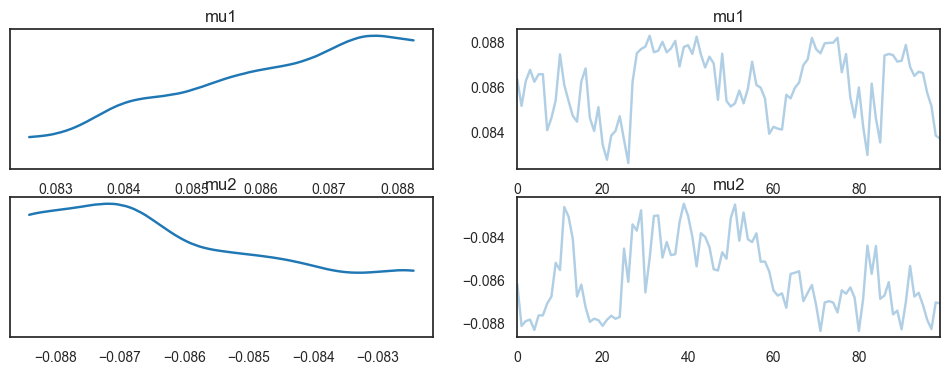

<Figure size 800x1000 with 0 Axes>

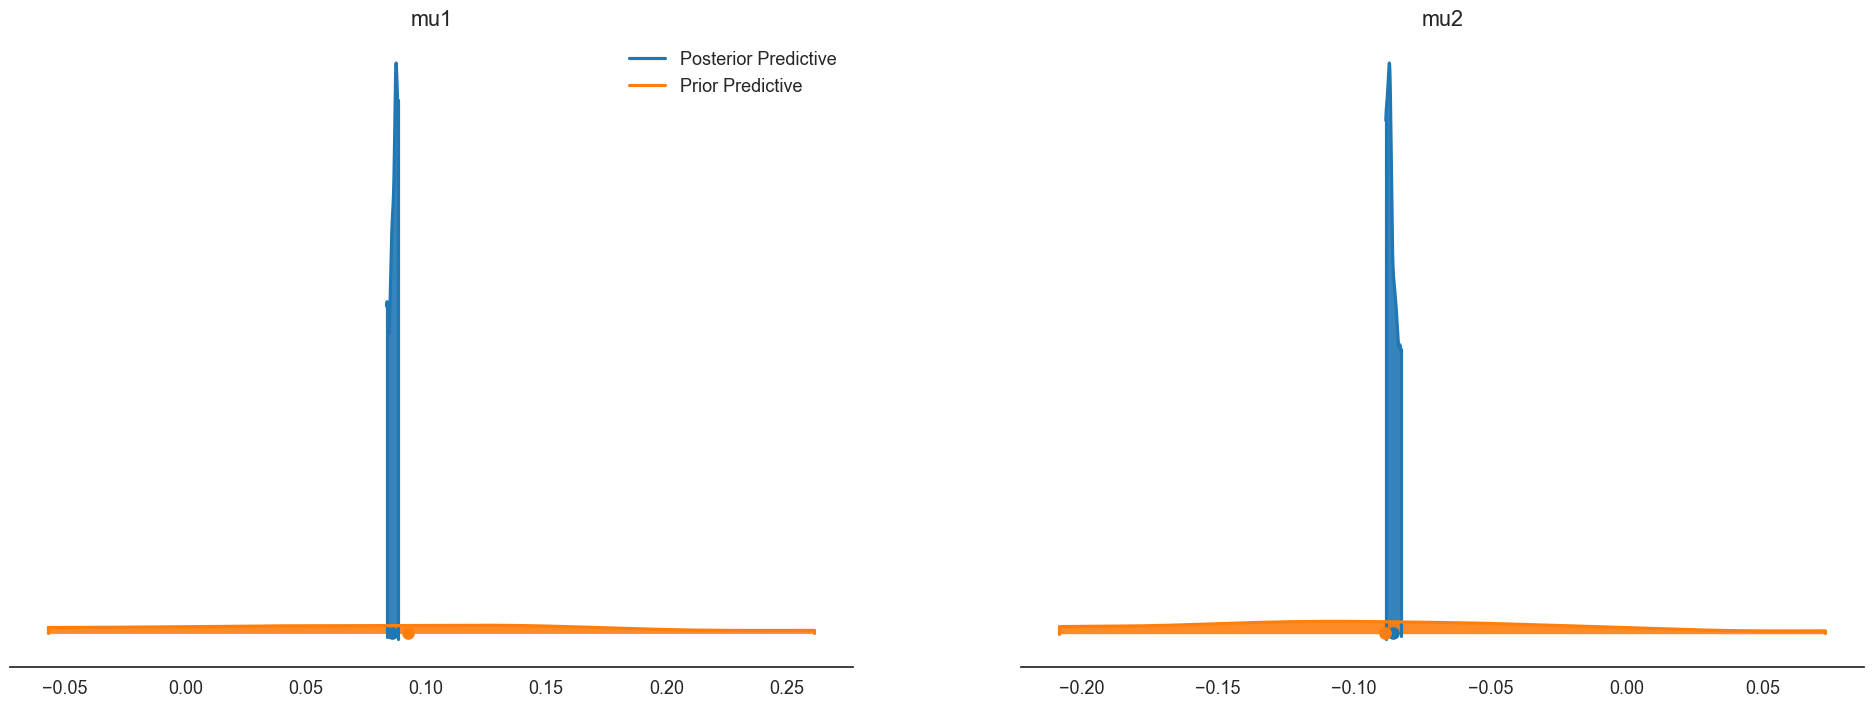

In [236]:
posterior_predictive = Predictive(model, samples)(geo_model_test, obs)

data_post = az.from_pyro(posterior=mcmc, prior=prior, posterior_predictive=posterior_predictive)
az.plot_trace(data_post)

plt.figure(figsize=(8,10))
az.plot_density(
data=[data_post.posterior, data_post.prior],
shade=.9,
#bw= 0.1,
var_names=['mu1', 'mu2'],
data_labels=["Posterior Predictive", "Prior Predictive"],
)
